# Multi-Output Deep Ensemble for a 1D Elastic Bar

This notebook uses `MultiOutputDeepEnsembleRegressor` to predict two coupled
outputs from a 1D elasticity problem: displacement and stress.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == 'sciml':
    PROJECT = ROOT.parents[1]
else:
    PROJECT = ROOT
SRC = PROJECT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

In [2]:
import math
import random

import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, TensorDataset

from deepuq.methods import MultiOutputDeepEnsembleRegressor
from deepuq.models import MLP

torch.manual_seed(13)
random.seed(13)

## Elastic-bar model

We solve

$$
-\frac{d}{dx}\left(E(x) \frac{du}{dx}\right) = f(x), \qquad u(0)=u(1)=0,
$$

and predict both displacement $u(x)$ and stress

$$
\sigma(x) = E(x) u'(x).
$$

In [3]:
def solve_bar(params, n_grid=128):
    amp, mode, e0, grad = params
    x = torch.linspace(0.0, 1.0, n_grid)
    h = float(x[1] - x[0])
    E = e0 * (1.0 + grad * (x - 0.5))
    f = amp * torch.sin(math.pi * mode * x)
    interior = n_grid - 2
    A = torch.zeros(interior, interior)
    rhs = f[1:-1].clone()
    for i in range(interior):
        idx = i + 1
        em = 2.0 * E[idx - 1] * E[idx] / (E[idx - 1] + E[idx])
        ep = 2.0 * E[idx + 1] * E[idx] / (E[idx + 1] + E[idx])
        A[i, i] = (em + ep) / h**2
        if i > 0:
            A[i, i - 1] = -em / h**2
        if i < interior - 1:
            A[i, i + 1] = -ep / h**2
    interior_u = torch.linalg.solve(A, rhs)
    u = torch.zeros_like(x)
    u[1:-1] = interior_u
    du = torch.gradient(u, spacing=(x,), edge_order=1)[0]
    sigma = E * du
    return x, u, sigma

def sample_params(n, *, ood=False):
    rows = []
    for _ in range(n):
        if ood:
            rows.append((random.uniform(1.2, 1.8), random.uniform(2.5, 4.0), random.uniform(0.8, 1.2), random.uniform(0.3, 0.6)))
        else:
            rows.append((random.uniform(0.5, 1.2), random.uniform(1.0, 2.2), random.uniform(0.9, 1.1), random.uniform(-0.2, 0.2)))
    return rows

def make_dataset(rows, n_grid=128):
    feats = []
    targets = []
    curves = []
    for params in rows:
        x, u, sigma = solve_bar(params, n_grid)
        param_tensor = torch.tensor(params, dtype=torch.float32).repeat(n_grid, 1)
        feats.append(torch.cat([x.unsqueeze(1), param_tensor], dim=1))
        targets.append(torch.stack([u, sigma], dim=1))
        curves.append((x, u, sigma, params))
    return torch.cat(feats), torch.cat(targets), curves

In [4]:
train_x, train_y, _ = make_dataset(sample_params(80))
test_x, test_y, test_curves = make_dataset(sample_params(20))
loader = DataLoader(TensorDataset(train_x, train_y), batch_size=256, shuffle=True)
ensemble = MultiOutputDeepEnsembleRegressor([MLP(5, [64, 64, 64], 2, p_drop=0.0) for _ in range(5)])
ensemble.fit(loader, epochs=90, lr=1e-3, weight_decay=1e-5, seed=90)

MultiOutputDeepEnsembleRegressor(
  (models): ModuleList(
    (0-4): 5 x MLP(
      (net): Sequential(
        (0): Linear(in_features=5, out_features=64, bias=True)
        (1): ReLU()
        (2): Dropout(p=0.0, inplace=False)
        (3): Linear(in_features=64, out_features=64, bias=True)
        (4): ReLU()
        (5): Dropout(p=0.0, inplace=False)
        (6): Linear(in_features=64, out_features=64, bias=True)
        (7): ReLU()
        (8): Dropout(p=0.0, inplace=False)
        (9): Linear(in_features=64, out_features=2, bias=True)
      )
    )
  )
)

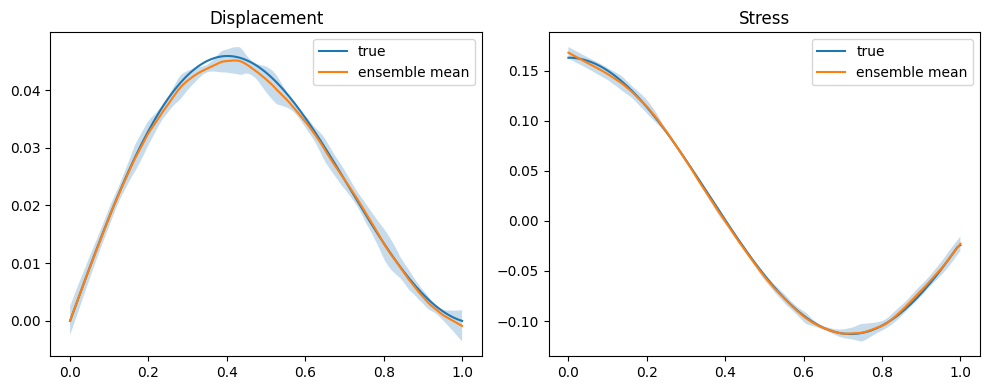

In [5]:
x, u_true, sigma_true, params = test_curves[0]
feats = torch.cat([x.unsqueeze(1), torch.tensor(params, dtype=torch.float32).repeat(x.numel(), 1)], dim=1)
uq = ensemble.predict_uq(feats)
pred = uq.mean
std = uq.total_var.sqrt()
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for idx, title, truth in [(0, 'Displacement', u_true), (1, 'Stress', sigma_true)]:
    axes[idx].plot(x, truth, label='true')
    axes[idx].plot(x, pred[:, idx], label='ensemble mean')
    axes[idx].fill_between(x.numpy(), (pred[:, idx] - 2 * std[:, idx]).numpy(), (pred[:, idx] + 2 * std[:, idx]).numpy(), alpha=0.25)
    axes[idx].set_title(title)
    axes[idx].legend()
plt.tight_layout()